# 03 - Baseline Models

Layer 1: standard sklearn novelty detectors (One-Class SVM, Isolation Forest, Local Outlier Factor, Elliptic Envelope) on signature features, plus a classical realized-volatility z-score baseline that skips signatures entirely -- the pointwise-statistics foil that motivates this whole project.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

macro_features = pd.read_parquet('../data/processed/macro_features.parquet')
macro_features.shape

(434, 780)

In [2]:
import yaml
cfg = yaml.safe_load(open('../configs/horizons.yaml'))
periods = cfg['reference_periods']

# Any window whose end-date falls inside ANY of the auto-detected calm
# periods counts as reference/training data -- pooling across all of them
# (rather than the single 2023 stretch this used to be) is what fixes the
# too-few-training-samples warnings seen below in the original single-period
# setup (LOF's n_neighbors override, EllipticEnvelope's rank-deficient fit).
train_mask = pd.Series(False, index=macro_features.index)
for p in periods:
    train_mask |= (macro_features.index >= pd.Timestamp(p['start'], tz='UTC')) & \
                  (macro_features.index <= pd.Timestamp(p['end'], tz='UTC'))
X_train = macro_features.loc[train_mask].to_numpy()
X_all = macro_features.to_numpy()
print('train windows:', X_train.shape[0], '/ total windows:', X_all.shape[0])

train windows: 164 / total windows: 434


In [3]:
from src.models.baselines import fit_sklearn_baselines, score_sklearn_baselines

models = fit_sklearn_baselines(X_train)
scores = score_sklearn_baselines(models, X_all)
scores_df = pd.DataFrame(scores, index=macro_features.index)
scores_df.head()

/Users/aayushjain/Desktop/BNY_Mellon_Proj/.venv/lib/python3.14/site-packages/sklearn/covariance/_robust_covariance.py:793: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


,one_class_svm,isolation_forest,local_outlier_factor,elliptic_envelope
window_end,,,,
2014-10-16 00:00:00+00:00,-0.012132,-0.154340,15.982879,2.266052e+05
2014-10-26 00:00:00+00:00,-0.019431,-0.193863,7.570527,1.621528e+04
2014-11-05 00:00:00+00:00,-0.014194,-0.166217,5.903445,6.850625e+04
2014-11-15 00:00:00+00:00,-0.011526,-0.116796,13.851723,5.833105e+05
2014-11-25 00:00:00+00:00,0.010543,-0.121556,26.178160,1.202290e+06


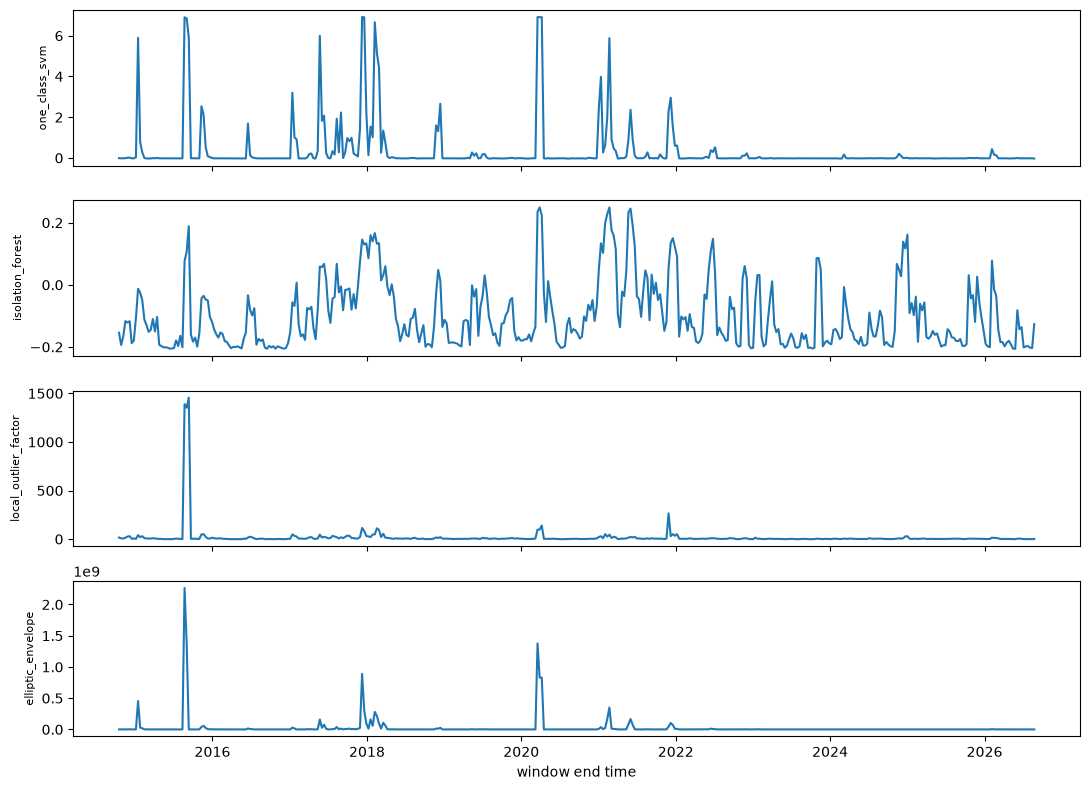

In [4]:
fig, axes = plt.subplots(len(scores_df.columns), 1, figsize=(11, 8), sharex=True)
for ax, col in zip(axes, scores_df.columns):
    ax.plot(scores_df.index, scores_df[col])
    ax.set_ylabel(col, fontsize=8)
plt.xlabel('window end time')
plt.tight_layout()
plt.savefig('../reports/baseline_scores_macro.png', dpi=120)
plt.show()

## Classical realized-volatility baseline (no signatures)

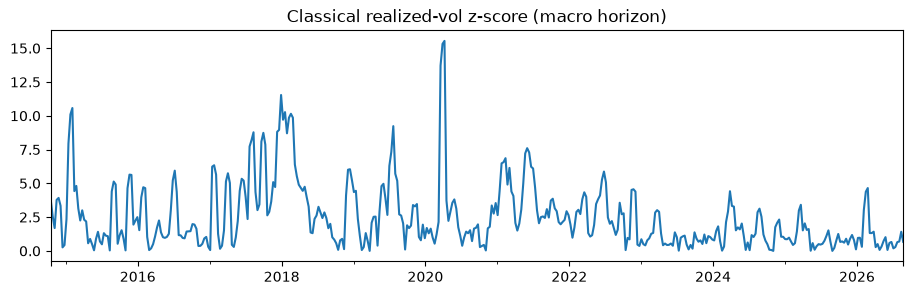

In [5]:
from src.features.pipeline import raw_paths_for_horizon, HorizonConfig
from src.models.baselines import fit_realized_vol_reference, realized_vol_zscore
from src.ingestion.yahoo import load_daily

macro_cfg = HorizonConfig.from_dict('macro', cfg['horizons']['macro'])
daily = load_daily(cfg['yahoo_ticker'])
if daily.index.tz is None:
    daily.index = daily.index.tz_localize('UTC')

end_times, raw_paths = raw_paths_for_horizon(daily, macro_cfg)
return_channel_idx = macro_cfg.channels.index('log_return')

ref_raw_paths = []
for p in periods:
    period_daily = daily.loc[p['start']:p['end']]
    _, period_raw = raw_paths_for_horizon(period_daily, macro_cfg)
    ref_raw_paths.extend(period_raw)
vol_mean, vol_std = fit_realized_vol_reference(ref_raw_paths, return_channel_idx)

vol_scores = realized_vol_zscore(raw_paths, return_channel_idx, vol_mean, vol_std)
vol_series = pd.Series(vol_scores, index=pd.DatetimeIndex(end_times))
vol_series.plot(figsize=(11, 3), title='Classical realized-vol z-score (macro horizon)')
plt.show()